# Clustering de Productos (Servicios en Contrataciones Públicas)

### Carga de las librerías de Python necesarias

In [4]:
!conda install -c conda-forge wordcloud -y
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sqlalchemy import create_engine
from wordcloud import WordCloud

# Conexión a la BD
conn_str = (
    "mssql+pyodbc://DESKTOP-N55HPMR/I_DE_NEGOCIOS_BD_NUEVO"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)
engine = create_engine(conn_str)

Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\Ronny\anaconda3

  added / updated specs:
    - wordcloud


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.6.15  |       h4c7d964_0         148 KB  conda-forge
    certifi-2025.6.15          |     pyhd8ed1ab_0         152 KB  conda-forge
    conda-24.11.3              |  py312h2e8e312_0         1.1 MB  conda-forge
    libexpat-2.6.3             |       he0c23c2_0         136 KB  conda-forge
    libsqlite-3.50.2           |       hf5d6505_0         1.2 MB  conda-forge
    libzlib-1.2.13             |       h2466b09_6          55 KB  conda-forge
    openssl-3.5.0              |       ha4e3fda_1         8.6 MB  conda-forge
    python-3.12.3              |h2628c8c_0_cpython        15.4 MB  conda-forge
    python_abi-3.12    

## 1. Análisis Exploratorio de Objetos Contractuales

In [9]:
# Consulta para obtener datos de productos/servicios
query_productos = """
SELECT 
    i.objeto_contractual,
    i.estado_item,
    i.moneda,
    AVG(h.monto_adjudicado_item) AS monto_promedio,
    COUNT(h.id_hecho) AS frecuencia,
    AVG(DATEDIFF(DAY, h.fecha_convocatoria, h.fecha_buenapro)) AS duracion_promedio_dias
FROM hechos_contrataciones h
JOIN dim_item i ON h.id_item = i.id_item
GROUP BY i.objeto_contractual, i.estado_item, i.moneda
HAVING COUNT(h.id_hecho) > 3  -- Filtramos objetos con al menos 3 contrataciones
"""

df_productos = pd.read_sql(query_productos, engine)

# Limpieza básica
df_productos['objeto_contractual'] = df_productos['objeto_contractual'].str.lower().str.strip()
print(f"📊 Total de objetos contractuales únicos: {len(df_productos)}")

📊 Total de objetos contractuales únicos: 9


## 2. Preprocesamiento para Clustering

In [11]:
# Convertir variables categóricas
df_encoded = pd.get_dummies(df_productos[['estado_item', 'moneda']])

# Variables numéricas
numeric_cols = ['monto_promedio', 'frecuencia', 'duracion_promedio_dias']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_productos[numeric_cols])

# Combinar datos
X = pd.concat([
    pd.DataFrame(df_scaled, columns=numeric_cols),
    df_encoded
], axis=1)

# Reducción de dimensionalidad (opcional)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

## 3. Determinación del Número Óptimo de Clusters

C:\Users\Ronny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Ronny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Ronny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Ronny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

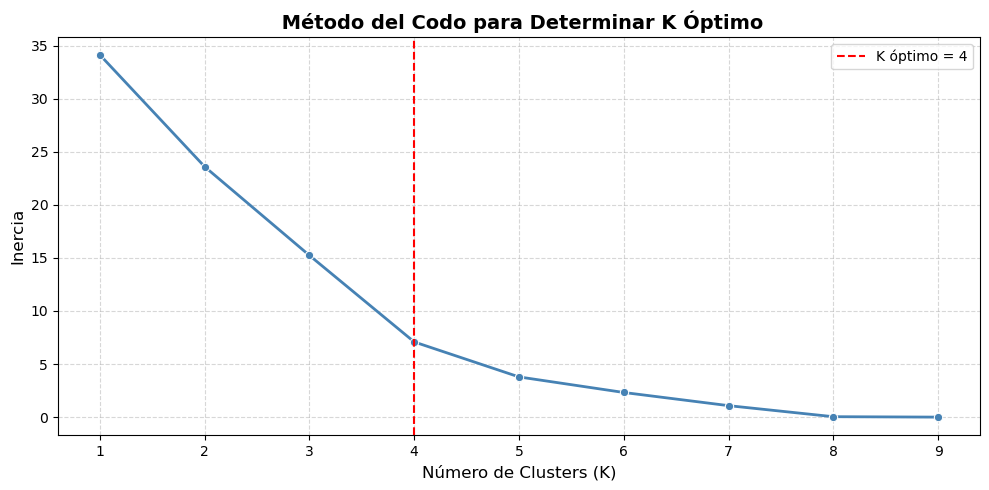

In [21]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator

# Ajustar rango según cantidad de muestras
k_range = range(1, min(len(X), 10) + 1)

inertia = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Detectar codo si es posible
knee = KneeLocator(k_range, inertia, curve="convex", direction="decreasing")

# Visualización
plt.figure(figsize=(10, 5))
sns.lineplot(x=list(k_range), y=inertia, marker='o', linewidth=2, color='steelblue')
plt.title(" Método del Codo para Determinar K Óptimo", fontsize=14, fontweight="bold")
plt.xlabel("Número de Clusters (K)", fontsize=12)
plt.ylabel("Inercia", fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)

if knee.knee:
    plt.axvline(knee.knee, color='red', linestyle='--', label=f'K óptimo = {knee.knee}')
    plt.legend()

plt.tight_layout()
plt.show()

## 4. Aplicación de K-Means Clustering

In [22]:
# Configuración final de clusters (basado en el método del codo)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df_productos['cluster'] = kmeans.fit_predict(X)

# Añadir componentes principales para visualización
df_productos['pca_1'] = X_pca[:, 0]
df_productos['pca_2'] = X_pca[:, 1]

# Analizar clusters
cluster_stats = df_productos.groupby('cluster').agg({
    'monto_promedio': ['mean', 'median'],
    'frecuencia': ['mean', 'median'],
    'duracion_promedio_dias': ['mean', 'median'],
    'objeto_contractual': 'count'
}).round(2)

print("📌 Estadísticas por Cluster:")
display(cluster_stats)

📌 Estadísticas por Cluster:


C:\Users\Ronny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


monto_promedio             frecuencia         duracion_promedio_dias  \
                  mean      median       mean  median                   mean   
cluster                                                                        
0           1126512.27  1013768.00     102.67    42.0                   3.00   
1           1267007.81  1267007.81      87.00    87.0                  14.00   
2           8111341.21  7929786.79     151.00   172.0                   3.33   
3           1611616.08  1611616.08    2907.50  2907.5                   4.00   

               objeto_contractual  
        median              count  
cluster                            
0          3.0                  3  
1         14.0                  1  
2          2.0                  3  
3          4.0                  2

## 5. Visualización de Resultados

### Gráfico de Dispersión PCA

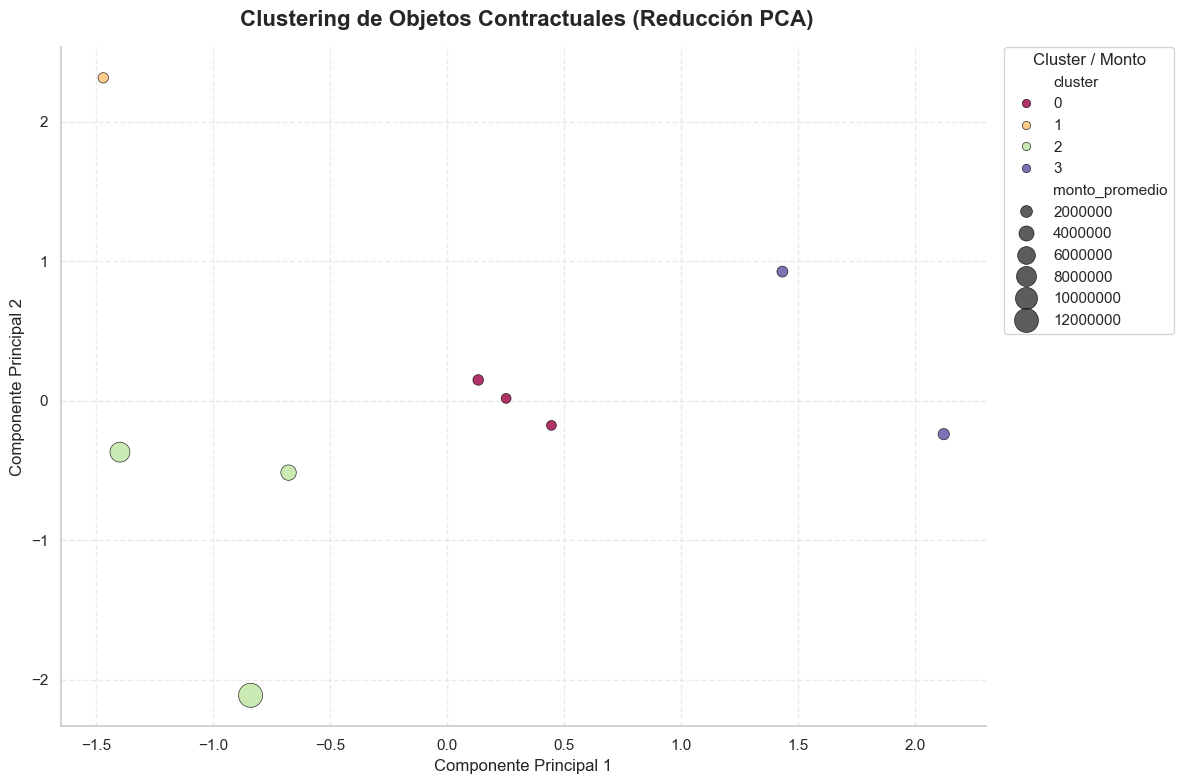

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Estilo limpio
sns.set_theme(style="whitegrid")

# Crear figura
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(
    data=df_productos,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    size='monto_promedio',
    palette='Spectral',
    sizes=(50, 300),
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    legend='brief'
)

# Títulos y ejes
ax.set_title(' Clustering de Objetos Contractuales (Reducción PCA)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Componente Principal 1', fontsize=12)
ax.set_ylabel('Componente Principal 2', fontsize=12)
ax.tick_params(labelsize=11)

# Bordes y rejilla corregidos
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)

# Leyenda optimizada
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    title='Cluster / Monto',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0.
)

plt.tight_layout()
plt.show()

### Nube de Palabras por Cluster

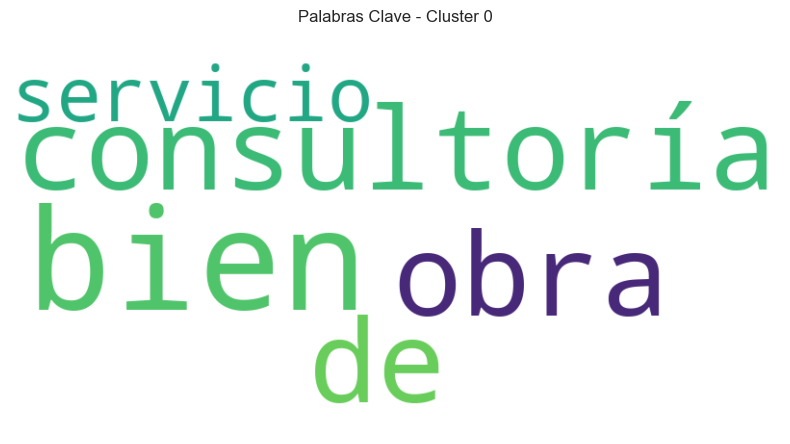

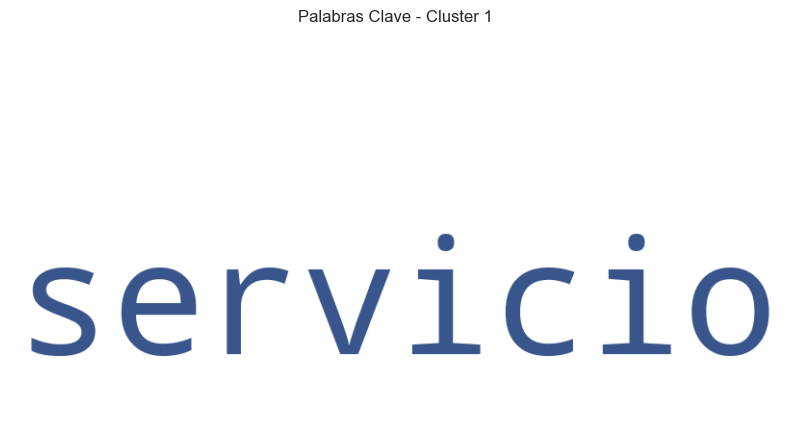

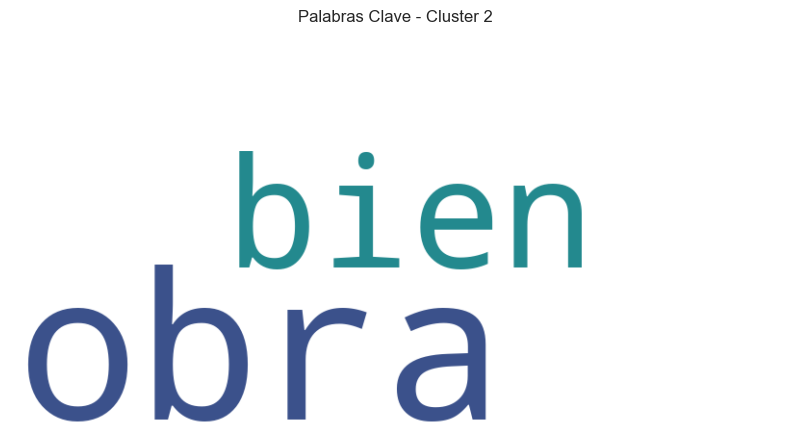

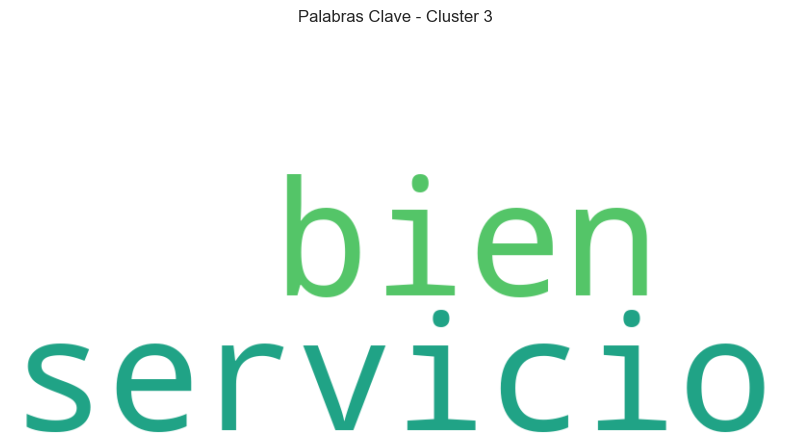

In [27]:
for cluster in sorted(df_productos['cluster'].unique()):
    text = ' '.join(df_productos[df_productos['cluster'] == cluster]['objeto_contractual'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Palabras Clave - Cluster {cluster}', pad=20)
    plt.axis('off')
    plt.show()

### Heatmap de Características

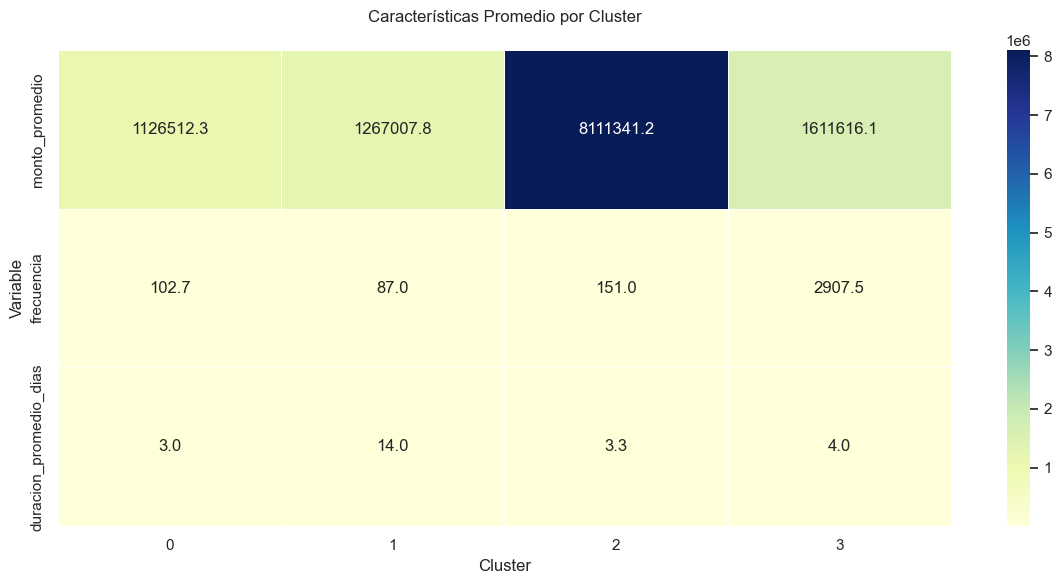

In [32]:
plt.figure(figsize=(12, 6))
cluster_means = df_productos.groupby('cluster')[numeric_cols].mean()
sns.heatmap(
    cluster_means.T,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',
    linewidths=.5
)
plt.title('Características Promedio por Cluster', pad=20)
plt.xlabel('Cluster')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### 6. Interpretación de Clusters

### Cluster 0: Contrataciones Medianas Frecuentes

* Monto promedio: S/1,126,512 (mediana: S/1,013,768)

* Frecuencia: 102.7 contrataciones (mediana 42)

* Duración promedio: 3 días

* Cantidad de objetos: 3 tipos

Interpretación: Este cluster representa objetos contractuales con montos medianos pero con alta frecuencia de contratación. Son procesos relativamente rápidos (3 días en promedio) que se repiten con regularidad. Podrían ser suministros o servicios recurrentes que las entidades necesitan periódicamente

### Cluster 1: Contratación Única Especial

* Monto promedio: S/1,267,008

* Frecuencia: 87 contrataciones (único objeto en este cluster)

* Duración promedio: 14 días

* Cantidad de objetos: 1 tipo

Interpretación: Se trata de un objeto contractual único con características especiales: monto similar al Cluster 0 pero con duración más prolongada (14 días). Podría ser un servicio especializado que requiere más tiempo de evaluación.

### Cluster 2: Mega Contrataciones

* Monto promedio: S/8,111,341 (mediana: S/7,929,787)

* Frecuencia: 151 contrataciones

* Duración promedio: 3.33 días

* Cantidad de objetos: 3 tipos

Interpretación: Este cluster agrupa los objetos contractuales con los montos más altos, casi 8 veces mayores que el promedio general. A pesar de los altos montos, la duración del proceso es similar a los del Cluster 0. Podrían ser proyectos de infraestructura mayor o adquisiciones de equipos costosos.

## Cluster 3: Contrataciones Masivas Recurrentes

* Monto promedio: S/1,611,616

* Frecuencia: 2,907.5 contrataciones (valor extremadamente alto)

* Duración promedio: 4 días

* Cantidad de objetos: 2 tipos

Interpretación: Este es el cluster más interesante, con una frecuencia de contratación extraordinariamente alta (casi 3,000 veces) pero con montos moderados. Podrían ser suministros básicos que las entidades adquieren constantemente en grandes volúmenes (como materiales de oficina, combustibles o alimentos).

### Observaciones Generales:
1. Duración de procesos: La mayoría de los clusters muestran procesos rápidos (3-4 días), excepto el Cluster 1 (14 días).

2. Relación monto-frecuencia: Existe una relación inversa entre el monto promedio y la frecuencia de contratación, excepto en el Cluster 3 que rompe este patrón.

3. Distribución de objetos: Los 9 objetos contractuales se distribuyen desigualmente entre los clusters, con concentración en los Clusters 0 y 2 (3 objetos cada uno).

4. Valores atípicos: El Cluster 3 muestra características extremas en frecuencia, lo que sugiere que podría tratarse de objetos contractuales muy específicos y de uso masivo.